In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Waypoints

In [53]:
df = pd.read_csv('aggregated_waypoints.csv', converters={'feas': ast.literal_eval, 'time': ast.literal_eval})
print(f"Dataset shape: {df.shape}")
print(f"Total records: {len(df)}")

Dataset shape: (100, 8)
Total records: 100


In [54]:
df['feas'] = df['feas'].apply(lambda x: [int(i) for i in x])
df['time'] = df['time'].apply(lambda x: [float(i) for i in x])

In [55]:
for i in range(len(df)):
    df.at[i, 'time'] = [int(np.ceil(t / 0.01)) for t in df.at[i, 'time']]

In [56]:
# only keep rows with agent_number 0
df = df[df['agent_number'] != 1]
print(f"After filtering for agent_number 0: {df.shape}")

After filtering for agent_number 0: (100, 8)


In [57]:
# add a column that specifies the length of the time list
df['length'] = df['time'].apply(lambda x: len(x))
df

,file_id,agent_number,file_number,feas,time,evals,plan,planID,length
0,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 93, 95, 6, 12, 8, 33, 91, 23, 91, 10, 92,...","[9, 88, 89, 5, 11, 7, 29, 81, 21, 84, 8, 86, 2...","[[pick_touch, objectA, floor, ego], [place_str...",0,500
1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12,...","[10, 82, 9, 7, 10, 7, 9, 81, 14, 76, 8, 10, 10...","[[pick_touch, objectA, floor, ego], [place_str...",1,500
2,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 92, 91, 6, 13, 6, 11, 65, 91, 91, 10, 91, ...","[8, 84, 82, 6, 11, 5, 9, 59, 83, 81, 10, 83, 7...","[[pick_touch, objectA, floor, ego], [place_str...",2,500
3,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[24, 92, 10, 10, 12, 13, 77, 48, 91, 74, 9, 91...","[22, 84, 8, 9, 10, 12, 69, 44, 83, 69, 7, 81, ...","[[pick_touch, objectA, floor, ego], [place_str...",3,500
4,0,0,0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 9, 66, 88, 11, 7, 13, 92, 14, 91, 10, 91,...","[13, 7, 61, 81, 9, 6, 11, 86, 12, 82, 9, 83, 8...","[[pick_touch, objectA, floor, ego], [place_str...",4,500
...,...,...,...,...,...,...,...,...,...
95,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 104, 37, 122, 122, 17, 21, 17, 52, 68, 51...","[12, 94, 30, 106, 104, 13, 17, 14, 44, 61, 44,...","[[pick_touch, objectA, floor, ego], [place_str...",45,500
96,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[14, 123, 16, 121, 123, 14, 122, 34, 31, 9, 19...","[11, 112, 12, 107, 107, 11, 107, 29, 26, 8, 15...","[[pick_touch, objectA, floor, ego], [place_str...",46,500
97,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 32, 11, 122, 122, 26, 122, 16, 23, 12, 22...","[12, 29, 9, 107, 106, 22, 106, 12, 18, 11, 18,...","[[pick_touch, objectA, floor, ego], [place_str...",47,500
98,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[15, 125, 16, 13, 24, 7, 17, 33, 13, 12, 15, 1...","[14, 111, 13, 9, 20, 5, 14, 29, 11, 11, 12, 10...","[[pick_touch, objectA, floor, ego], [place_str...",48,500


In [58]:
# add column for the average of the feas list
df['feas_avg'] = df['feas'].apply(lambda x: np.mean(x))
# and average of the time list seperate for feas and infeas times
df['feas_time_avg'] = df.apply(lambda row: np.mean([row['time'][i] for i in range(len(row['feas'])) if row['feas'][i] == 1]) if any(row['feas']) else np.nan, axis=1)
df['infeas_time_avg'] = df.apply(lambda row: np.mean([row['time'][i] for i in range(len(row['feas'])) if row['feas'][i] == 0]) if any([1 - f for f in row['feas']]) else np.nan, axis=1)
df

,file_id,agent_number,file_number,feas,time,evals,plan,planID,length,feas_avg,feas_time_avg,infeas_time_avg
0,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 93, 95, 6, 12, 8, 33, 91, 23, 91, 10, 92,...","[9, 88, 89, 5, 11, 7, 29, 81, 21, 84, 8, 86, 2...","[[pick_touch, objectA, floor, ego], [place_str...",0,500,0.048,7.541667,41.119748
1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12,...","[10, 82, 9, 7, 10, 7, 9, 81, 14, 76, 8, 10, 10...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.927273,39.795506
2,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 92, 91, 6, 13, 6, 11, 65, 91, 91, 10, 91, ...","[8, 84, 82, 6, 11, 5, 9, 59, 83, 81, 10, 83, 7...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.128,6.046875,39.410550
3,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[24, 92, 10, 10, 12, 13, 77, 48, 91, 74, 9, 91...","[22, 84, 8, 9, 10, 12, 69, 44, 83, 69, 7, 81, ...","[[pick_touch, objectA, floor, ego], [place_str...",3,500,0.044,5.363636,39.232218
4,0,0,0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 9, 66, 88, 11, 7, 13, 92, 14, 91, 10, 91,...","[13, 7, 61, 81, 9, 6, 11, 86, 12, 82, 9, 83, 8...","[[pick_touch, objectA, floor, ego], [place_str...",4,500,0.046,5.956522,42.142558
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 104, 37, 122, 122, 17, 21, 17, 52, 68, 51...","[12, 94, 30, 106, 104, 13, 17, 14, 44, 61, 44,...","[[pick_touch, objectA, floor, ego], [place_str...",45,500,0.020,8.900000,52.483673
96,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[14, 123, 16, 121, 123, 14, 122, 34, 31, 9, 19...","[11, 112, 12, 107, 107, 11, 107, 29, 26, 8, 15...","[[pick_touch, objectA, floor, ego], [place_str...",46,500,0.018,8.888889,52.173116
97,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[14, 32, 11, 122, 122, 26, 122, 16, 23, 12, 22...","[12, 29, 9, 107, 106, 22, 106, 12, 18, 11, 18,...","[[pick_touch, objectA, floor, ego], [place_str...",47,500,0.026,8.461538,52.909651
98,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[15, 125, 16, 13, 24, 7, 17, 33, 13, 12, 15, 1...","[14, 111, 13, 9, 20, 5, 14, 29, 11, 11, 12, 10...","[[pick_touch, objectA, floor, ego], [place_str...",48,500,0.012,8.833333,56.429150


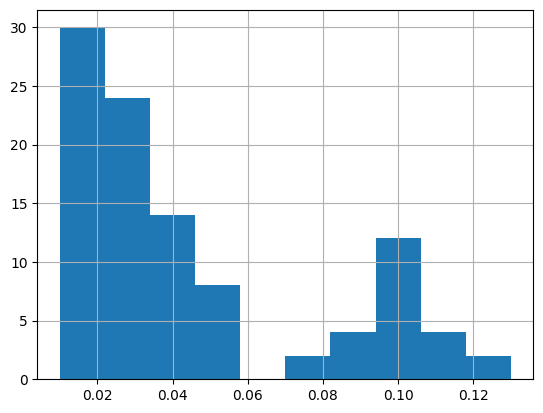

In [59]:
# do a histogram of fead_avg
df['feas_avg'].hist()
plt.show()

In [60]:
df.sort_values('feas_avg', ascending=False).head(20)

,file_id,agent_number,file_number,feas,time,evals,plan,planID,length,feas_avg,feas_time_avg,infeas_time_avg
52,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 91, 6, 13, 6, 11, 65, 91, 90, 10, 91, 7, ...","[82, 82, 6, 10, 5, 9, 59, 83, 81, 9, 82, 7, 60...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.130,5.969231,39.349425
2,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 92, 91, 6, 13, 6, 11, 65, 91, 91, 10, 91, ...","[8, 84, 82, 6, 11, 5, 9, 59, 83, 81, 10, 83, 7...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.128,6.046875,39.410550
51,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12, 12,...","[82, 9, 7, 10, 7, 9, 81, 14, 75, 9, 10, 10, 46...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.909091,39.606742
1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12,...","[10, 82, 9, 7, 10, 7, 9, 81, 14, 76, 8, 10, 10...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.927273,39.795506
24,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 92, 91, 6, 92, 91, 92, 91, 91, 6, 12, 12, ...","[6, 85, 83, 5, 88, 83, 87, 82, 84, 6, 11, 10, ...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.849057,41.185682
74,2000,2,0,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[93, 91, 6, 92, 91, 91, 91, 91, 6, 12, 12, 14,...","[86, 83, 6, 87, 83, 84, 83, 82, 6, 11, 10, 12,...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.830189,41.158837
56,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 91, 7, 16, 7, 12, 10, 91, 91, 9, 93, 90, ...","[9, 83, 7, 14, 6, 10, 8, 84, 82, 9, 88, 82, 82...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.102,5.627451,38.095768
70,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[91, 24, 91, 38, 66, 90, 91, 21, 92, 9, 6, 16,...","[83, 21, 82, 33, 58, 81, 81, 19, 82, 6, 6, 14,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.862745,41.523385
20,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[15, 92, 24, 91, 38, 66, 90, 91, 21, 91, 9, 6,...","[14, 84, 21, 82, 33, 58, 81, 81, 19, 83, 6, 6,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.843137,41.712695
6,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 10, 92, 7, 16, 7, 12, 10, 92, 91, 9, 91, 9...","[6, 8, 87, 7, 14, 6, 10, 9, 86, 82, 9, 83, 83,...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.100,5.700000,38.168889


In [61]:
def get_chain_probs(feas_array, time_array):
    feas_array = np.array(feas_array) 
    time_array = np.array(time_array)
    # substract 1 from ever time in the time array
    time_array = time_array - 1
    feas_indices = feas_array == 1
    feas_times = time_array[feas_indices]
    infeas_times = time_array[~feas_indices]
    feas_values, feas_counts = np.unique(feas_times, return_counts=True)
    infeas_values, infeas_counts = np.unique(infeas_times, return_counts=True)
    # get all value
    all_values = np.union1d(feas_values, infeas_values)
    # make feas_counts sorted according to all_values, filling missing values with 0
    feas_counts_full = np.zeros_like(all_values)
    infeas_counts_full = np.zeros_like(all_values)
    for i, v in enumerate(all_values):
        if v in feas_values:
            feas_counts_full[i] = feas_counts[feas_values == v][0]
        if v in infeas_values:
            infeas_counts_full[i] = infeas_counts[infeas_values == v][0]
    all_counts = feas_counts_full + infeas_counts_full
    cum_sum_counts = np.cumsum(all_counts[::-1])[::-1]
    feas_array = feas_counts_full / cum_sum_counts
    infeas_array = infeas_counts_full / cum_sum_counts
    
    # return 4 np arrays: done_values, done_times, fail_values, fail_times. The done_times are the times where there is a positive probability of success, and the fail_times are the times where there is a positive probability of failure. The done_values and fail_values are the corresponding probabilities.
    done_values = feas_array[feas_array > 0]
    done_times = all_values[feas_array > 0]
    fail_values = infeas_array[infeas_array > 0]
    fail_times = all_values[infeas_array > 0]
    return done_values, done_times, fail_values, fail_times

In [62]:
# for each row in the dataframe, get the chain probabilities and store them in a json file. The keys are the planID and the values are dictionaries with the following keys: done_transitions, done_times, fail_transitions, fail_times, plan.
import json
chain_probs = {}
for i, row in df.iterrows():
    plan_id = row['planID']
    feas_array = row['feas']
    time_array = row['time']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
    chain_probs[plan_id] = {
        'done_transitions': done_values.tolist(),
        'done_times': done_times.tolist(),
        'fail_transitions': fail_values.tolist(),
        'fail_times': fail_times.tolist(),
        'plan': row['plan']
    }

with open('waypoints_chains.json', 'w') as f:
    json.dump(chain_probs, f, indent=4)

In [63]:
import numpy as np
import enum

class BanditType(enum.Enum):
    LOOP=1
    LINE=2

class MarkovChain:
    beta = 0.9999
    def __init__(self, done_transitions: np.array, done_times: np.array, fail_transitions: np.array, fail_times: np.array, type: BanditType):
        # the arrays are interpreted as:
        # state done_times[i] has a transition to DONE with probability done_transitions[i]
        self.done_transitions = done_transitions
        self.done_times = done_times
        self.fail_transitions = fail_transitions
        self.fail_times = fail_times
        self.type = type
        if 0 not in self.done_times:
            self.done_times = np.concatenate(([0], self.done_times))
            self.done_transitions = np.concatenate(([0.0], self.done_transitions))
        if 0 not in self.fail_times:
            self.fail_times = np.concatenate(([0], self.fail_times))
            self.fail_transitions = np.concatenate(([0.0], self.fail_transitions))
        if self.fail_times[-1] == self.done_times[-1]:
            self.fail_transitions[-1] = 1- self.done_transitions[-1]
        elif self.fail_times[-1] < self.done_times[-1]:
            self.fail_times = np.concatenate((self.fail_times, [self.done_times[-1]]))
            self.fail_transitions = np.concatenate((self.fail_transitions, [1.0 - self.done_transitions[-1]]))
        else:
            self.fail_transitions[-1] = 1.0
        self.all_times = np.sort(np.unique(np.concatenate((self.done_times, self.fail_times))))

        # assert the the pair of arrays have the same length
        assert len(self.done_transitions) == len(self.done_times)
        assert len(self.fail_transitions) == len(self.fail_times)

        # assert that the transition probabilites are less than 1
        assert np.all((self.done_transitions >= 0) & (self.done_transitions <= 1))
        assert np.all((self.fail_transitions >= 0) & (self.fail_transitions <= 1))

    def step(self):
        done_index = 0
        fail_index = 0
        completed = False
        completed_state = 0
        prev_t = 0
        for i in range(len(self.all_times)):
            t = self.all_times[i]
            while prev_t < t:
                yield 0
                prev_t += 1
            p_done = 0.0
            p_fail = 0.0
            if done_index < len(self.done_times) and t == self.done_times[done_index]:
                p_done = self.done_transitions[done_index]
                done_index += 1
            if fail_index < len(self.fail_times) and t == self.fail_times[fail_index]:
                p_fail = self.fail_transitions[fail_index]
                fail_index += 1
            # sample according to the probabilities
            r = np.random.random()
            if r < p_done:
                completed = True
                completed_state = 1
                yield 1
            if r < p_done + p_fail:
                completed = True
                completed_state = -1
                yield -1
            else:
                yield 0
            prev_t = t + 1
        if completed:
            yield completed_state

    # I want to be able to do MarkovChain[i:j] to get a sub-chain
    def get_subchain(self, start, end):
        fail_indexes = (self.fail_times >= start) & (self.fail_times <= end)
        done_indexes = (self.done_times >= start) & (self.done_times <= end)
        if start == -np.inf:
            start = 0
        return MarkovChain(self.done_transitions[done_indexes], self.done_times[done_indexes] - start, self.fail_transitions[fail_indexes], self.fail_times[fail_indexes] - start, self.type)
    
    def get_gittins_numerator(self, next_layer_numerator=1/(1-beta)):
        # return the value a_0 = E[beta^T/(1-beta)|s0=0] and T is the hitting time in the DONE state. If the chain is not the last layer, next_layer_numerator is the numerator of the next layer.
        # in the following we solve the linear system a_t1 = beta**(t2-t1)*p_next*a_t2 + beta*p_done*next_layer_numerator + beta*p_fail*a_0 where a_s is E[beta^T/(1-beta)|s0=s]
        if self.type == BanditType.LOOP:
            size = len(self.all_times)
            matrix = np.zeros((size, size))
            rhs = np.zeros(size)
            done_index = 0
            fail_index = 0
            i = 0
            while i < len(self.all_times):
                t1 = self.all_times[i]
                if i < len(self.all_times) - 1:
                    t2 = self.all_times[i+1]
                p_done = 0.0
                p_fail = 0.0
                if done_index < len(self.done_times) and t1 == self.done_times[done_index]:
                    p_done = self.done_transitions[done_index]
                    done_index += 1
                if fail_index < len(self.fail_times) and t1 == self.fail_times[fail_index]:
                    p_fail = self.fail_transitions[fail_index]
                    fail_index += 1
                next_prob = 1.0 - p_done - p_fail
                matrix[i, 0] = MarkovChain.beta*p_fail
                rhs[i] = MarkovChain.beta*p_done*next_layer_numerator
                if i < len(self.all_times) - 1:
                    matrix[i, i+1] = MarkovChain.beta**(t2 - t1)*next_prob
                i += 1
            # solve the linear system
            a = np.linalg.solve(np.eye(size) - matrix, rhs)
            return a[0] # a[i] is a_i
        
        if self.type == BanditType.LINE:
            size = len(self.all_times)
            matrix = np.zeros((size, size))
            rhs = np.zeros(size)
            done_index = 0
            fail_index = 0
            i = 0
            while i < len(self.all_times):
                t1 = self.all_times[i]
                if i < len(self.all_times) - 1:
                    t2 = self.all_times[i+1]
                p_done = 0.0
                p_fail = 0.0
                if done_index < len(self.done_times) and t1 == self.done_times[done_index]:
                    p_done = self.done_transitions[done_index]
                    done_index += 1
                if fail_index < len(self.fail_times) and t1 == self.fail_times[fail_index]:
                    p_fail = self.fail_transitions[fail_index]
                    fail_index += 1
                next_prob = 1.0 - p_done - p_fail
                rhs[i] = MarkovChain.beta*p_done*next_layer_numerator
                if i < len(self.all_times) - 1:
                    matrix[i, i+1] = MarkovChain.beta**(t2 - t1)*next_prob
                i += 1
            # solve the linear system
            a = np.linalg.solve(np.eye(size) - matrix, rhs)
            return a[0] # a[i] is a_i
        
    def get_gittins_denominator_aux(self, next_layer_aux=0.0):
        # The denominator is 1/(1-beta) - E[beta**T/(1-beta)] where T is the hitting time in a FAIL state. We compute E[beta**T/(1-beta)] via solving a linear system similar to the numerator case. In this function we return E[beta**T/(1-beta)] and the caller can compute the denominator.
        if self.type == BanditType.LOOP:
            return next_layer_aux
        if self.type == BanditType.LINE:
            size = len(self.all_times)
            matrix = np.zeros((size, size))
            rhs = np.zeros(size)
            done_index = 0
            fail_index = 0
            i = 0
            while i < len(self.all_times):
                t1 = self.all_times[i]
                if i < len(self.all_times) - 1:
                    t2 = self.all_times[i+1]
                p_done = 0.0
                p_fail = 0.0
                if done_index < len(self.done_times) and t1 == self.done_times[done_index]:
                    p_done = self.done_transitions[done_index]
                    done_index += 1
                if fail_index < len(self.fail_times) and t1 == self.fail_times[fail_index]:
                    p_fail = self.fail_transitions[fail_index]
                    fail_index += 1
                next_prob = 1.0 - p_done - p_fail
                rhs[i] = MarkovChain.beta*p_done*next_layer_aux + MarkovChain.beta*p_fail*1/(1 - MarkovChain.beta)
                if i < len(self.all_times) - 1:
                    matrix[i, i+1] = MarkovChain.beta**(t2 - t1)*next_prob
                i += 1
            # solve the linear system
            c = np.linalg.solve(np.eye(size) - matrix, rhs)
            return c[0] # c[i] is c_i
    
    def get_stopping_time_and_gittins_parts(self, state, next_layer_numerator=1/(1-beta), next_layer_aux=0.0):
        start_index_chain = self.get_subchain(state, np.inf)
        optimal_stopping_time = None
        optimal_numerator = None
        optimal_denominator_aux = None
        optimal_gi = -np.inf
        for i in range(len(start_index_chain.all_times)):
            end_index_chain = start_index_chain.get_subchain(-np.inf, start_index_chain.all_times[i])
            numerator= end_index_chain.get_gittins_numerator(next_layer_numerator)
            denominator_aux = end_index_chain.get_gittins_denominator_aux(next_layer_aux)
            denominator = 1/(1-MarkovChain.beta)-denominator_aux
            gi = numerator/denominator
            if gi > optimal_gi:
                optimal_gi = gi
                optimal_stopping_time = start_index_chain.all_times[i]
                optimal_numerator = numerator
                optimal_denominator_aux = denominator_aux
        return optimal_stopping_time, optimal_numerator, optimal_denominator_aux


class BanditProcess:
    beta = 0.9999
    def __init__(self, markov_chains: list[MarkovChain], bandit_types: list[BanditType]):
        self.markov_chains = markov_chains
        self.bandit_types = bandit_types
        self.state = 0

    def get_gittins_index(self):
        next_layer_numerator = 1/(1-BanditProcess.beta)
        next_layer_aux = 0.0
        for i in reversed(range(len(self.markov_chains))):
            chain = self.markov_chains[i]
            chain.type = self.bandit_types[i]
            chain_state = self.state if i == 0 else 0
            stopping_time, numerator, denominator_aux = chain.get_stopping_time_and_gittins_parts(chain_state, next_layer_numerator, next_layer_aux)
            if chain.type == BanditType.LOOP:
                chain = chain.get_subchain(-np.inf, stopping_time)
                numerator = chain.get_gittins_numerator(next_layer_numerator)
                denominator_aux = chain.get_gittins_denominator_aux(next_layer_aux)
            next_layer_numerator = numerator
            next_layer_aux = denominator_aux
        gittins_index = numerator/(1/(1-BanditProcess.beta)-denominator_aux)
        return gittins_index, stopping_time

In [64]:
def compute_gi(row):
    feas_array = row['feas']
    time_array = row['time']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
    mc = MarkovChain(done_values, done_times, fail_values, fail_times, BanditType.LINE)
    bp = BanditProcess([mc], [BanditType.LINE])
    return bp.get_gittins_index()[0]

def compute_stopping_time(row):
    feas_array = row['feas']
    time_array = row['time']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
    mc = MarkovChain(done_values, done_times, fail_values, fail_times, BanditType.LINE)
    bp = BanditProcess([mc], [BanditType.LINE])
    return bp.get_gittins_index()[1]
    
df['stopping_time'] = df.apply(compute_stopping_time, axis=1)
df['gittins_index'] = df.apply(compute_gi, axis=1)

In [65]:
df.sort_values('gittins_index', ascending=False).head(10)

,file_id,agent_number,file_number,feas,time,evals,plan,planID,length,feas_avg,feas_time_avg,infeas_time_avg,stopping_time,gittins_index
52,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 91, 6, 13, 6, 11, 65, 91, 90, 10, 91, 7, ...","[82, 82, 6, 10, 5, 9, 59, 83, 81, 9, 82, 7, 60...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.130,5.969231,39.349425,6,0.994593
2,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 92, 91, 6, 13, 6, 11, 65, 91, 91, 10, 91, ...","[8, 84, 82, 6, 11, 5, 9, 59, 83, 81, 10, 83, 7...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.128,6.046875,39.410550,6,0.994412
51,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12, 12,...","[82, 9, 7, 10, 7, 9, 81, 14, 75, 9, 10, 10, 46...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.909091,39.606742,6,0.993443
56,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 91, 7, 16, 7, 12, 10, 91, 91, 9, 93, 90, ...","[9, 83, 7, 14, 6, 10, 8, 84, 82, 9, 88, 82, 82...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.102,5.627451,38.095768,6,0.993327
1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12,...","[10, 82, 9, 7, 10, 7, 9, 81, 14, 76, 8, 10, 10...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.927273,39.795506,6,0.993314
74,2000,2,0,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[93, 91, 6, 92, 91, 91, 91, 91, 6, 12, 12, 14,...","[86, 83, 6, 87, 83, 84, 83, 82, 6, 11, 10, 12,...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.830189,41.158837,5,0.993287
24,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 92, 91, 6, 92, 91, 92, 91, 91, 6, 12, 12, ...","[6, 85, 83, 5, 88, 83, 87, 82, 84, 6, 11, 10, ...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.849057,41.185682,5,0.993287
6,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 10, 92, 7, 16, 7, 12, 10, 92, 91, 9, 91, 9...","[6, 8, 87, 7, 14, 6, 10, 9, 86, 82, 9, 83, 83,...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.100,5.700000,38.168889,6,0.993185
20,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[15, 92, 24, 91, 38, 66, 90, 91, 21, 91, 9, 6,...","[14, 84, 21, 82, 33, 58, 81, 81, 19, 83, 6, 6,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.843137,41.712695,6,0.993179
70,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[91, 24, 91, 38, 66, 90, 91, 21, 92, 9, 6, 16,...","[83, 21, 82, 33, 58, 81, 81, 19, 82, 6, 6, 14,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.862745,41.523385,6,0.993177


In [66]:
df.sort_values('feas_avg', ascending=False).head(10)

,file_id,agent_number,file_number,feas,time,evals,plan,planID,length,feas_avg,feas_time_avg,infeas_time_avg,stopping_time,gittins_index
52,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 91, 6, 13, 6, 11, 65, 91, 90, 10, 91, 7, ...","[82, 82, 6, 10, 5, 9, 59, 83, 81, 9, 82, 7, 60...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.130,5.969231,39.349425,6,0.994593
2,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[9, 92, 91, 6, 13, 6, 11, 65, 91, 91, 10, 91, ...","[8, 84, 82, 6, 11, 5, 9, 59, 83, 81, 10, 83, 7...","[[pick_touch, objectA, floor, ego], [place_str...",2,500,0.128,6.046875,39.410550,6,0.994412
51,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12, 12,...","[82, 9, 7, 10, 7, 9, 81, 14, 75, 9, 10, 10, 46...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.909091,39.606742,6,0.993443
1,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 91, 11, 8, 11, 8, 11, 90, 17, 81, 10, 12,...","[10, 82, 9, 7, 10, 7, 9, 81, 14, 76, 8, 10, 10...","[[pick_touch, objectA, floor, ego], [place_str...",1,500,0.110,5.927273,39.795506,6,0.993314
24,0,0,0,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 92, 91, 6, 92, 91, 92, 91, 91, 6, 12, 12, ...","[6, 85, 83, 5, 88, 83, 87, 82, 84, 6, 11, 10, ...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.849057,41.185682,5,0.993287
74,2000,2,0,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[93, 91, 6, 92, 91, 91, 91, 91, 6, 12, 12, 14,...","[86, 83, 6, 87, 83, 84, 83, 82, 6, 11, 10, 12,...","[[pick_touch, objectC, floor, ego], [place_str...",24,500,0.106,5.830189,41.158837,5,0.993287
56,2000,2,0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 91, 7, 16, 7, 12, 10, 91, 91, 9, 93, 90, ...","[9, 83, 7, 14, 6, 10, 8, 84, 82, 9, 88, 82, 82...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.102,5.627451,38.095768,6,0.993327
70,2000,2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[91, 24, 91, 38, 66, 90, 91, 21, 92, 9, 6, 16,...","[83, 21, 82, 33, 58, 81, 81, 19, 82, 6, 6, 14,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.862745,41.523385,6,0.993177
20,0,0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[15, 92, 24, 91, 38, 66, 90, 91, 21, 91, 9, 6,...","[14, 84, 21, 82, 33, 58, 81, 81, 19, 83, 6, 6,...","[[pick_touch, objectB, floor, ego], [place_str...",20,500,0.102,5.843137,41.712695,6,0.993179
6,0,0,0,"[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 10, 92, 7, 16, 7, 12, 10, 92, 91, 9, 91, 9...","[6, 8, 87, 7, 14, 6, 10, 9, 86, 82, 9, 83, 83,...","[[pick_touch, objectA, floor, ego], [place_str...",6,500,0.100,5.700000,38.168889,6,0.993185


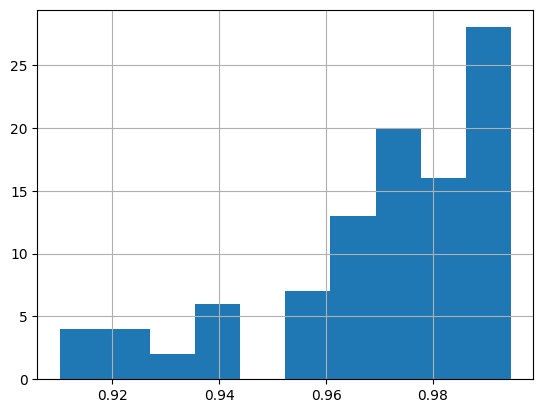

In [67]:
df['gittins_index'].hist()
plt.show()

In [68]:
# iterate through the rows of the dataframe. For each calculate the gittins index starting from state i = 0...stopping time. I want to see that until the stopping time the gittins index is increasing.
for i, row in df.iterrows():
    feas_array = row['feas']
    time_array = row['time']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
    mc = MarkovChain(done_values, done_times, fail_values, fail_times, BanditType.LINE)
    bp = BanditProcess([mc], [BanditType.LINE])
    gittins_indices = []
    for state in range(int(row['stopping_time'])):
        bp.state = state
        gi, _ = bp.get_gittins_index()
        if gi < row['gittins_index']:
            print(f"Row {i} has decreasing GI at state {state}: {gi} < {row['gittins_index']}")
            break
    

In [69]:
row0 = df.iloc[0]
feas_array = row0['feas']
time_array = row0['time']
done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
mc = MarkovChain(done_values, done_times, fail_values, fail_times, BanditType.LINE)
bp = BanditProcess([mc], [BanditType.LINE])
gi0 = bp.get_gittins_index()
bp.state = 6
gi1 = bp.get_gittins_index()
print(gi0, gi1)

(np.float64(0.9866052259568696), np.int64(5)) (np.float64(0.913313521244845), np.int64(1))


# RRTs

In [70]:
rrts = pd.read_csv('aggregated_rrt.csv')
rrts

,file_id,agent_number,file_number,feas,time,evals,plan,planID,actionNum,q0,qf
0,0,0,0,1,0.069543,7,"[[pick_touch, objectA, floor, ego], [place_str...",0,0,"[0, 0]","[3.56666, -2.07874]"
1,0,0,0,1,0.151618,15,"[[pick_touch, objectA, floor, ego], [place_str...",0,1,"[3.56666, -2.07874]","[-2.00145, 0.549192]"
2,0,0,0,1,0.179326,18,"[[pick_touch, objectA, floor, ego], [place_str...",0,2,"[-2.00145, 0.549192]","[-1.68079, -1.53427]"
3,0,0,0,1,0.027452,3,"[[pick_touch, objectA, floor, ego], [place_str...",0,3,"[-1.68079, -1.53427]","[-1.29668, -3.86407]"
4,0,0,0,1,0.065443,7,"[[pick_touch, objectA, floor, ego], [place_str...",0,4,"[-1.29668, -3.86407]","[1.46888, 3.05464]"
...,...,...,...,...,...,...,...,...,...,...,...
14239,2000,2,0,1,0.016040,2,"[[pick_touch, objectA, floor, ego], [place_str...",49,3,"[-1.61082, -1.52556]","[-2.06433, 0.553627]"
14240,2000,2,0,1,0.048535,5,"[[pick_touch, objectA, floor, ego], [place_str...",49,4,"[-2.06433, 0.553627]","[0.82167, -0.844951]"
14241,2000,2,0,1,0.013075,2,"[[pick_touch, objectA, floor, ego], [place_str...",49,5,"[0.82167, -0.844951]","[2.10645, -0.494849]"
14242,2000,2,0,1,0.049165,5,"[[pick_touch, objectA, floor, ego], [place_str...",49,6,"[2.10645, -0.494849]","[1.97436, 2.53547]"


In [71]:
rrts = rrts[rrts['agent_number'] == 0]
print(f"After filtering for agent_number 0: {rrts.shape}")

After filtering for agent_number 0: (7110, 11)


In [72]:
rrts['time'] = np.ceil(rrts['time'] / 0.01).astype(int)
rrts

/tmp/ipykernel_4711/2762280569.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rrts['time'] = np.ceil(rrts['time'] / 0.01).astype(int)


,file_id,agent_number,file_number,feas,time,evals,plan,planID,actionNum,q0,qf
0,0,0,0,1,7,7,"[[pick_touch, objectA, floor, ego], [place_str...",0,0,"[0, 0]","[3.56666, -2.07874]"
1,0,0,0,1,16,15,"[[pick_touch, objectA, floor, ego], [place_str...",0,1,"[3.56666, -2.07874]","[-2.00145, 0.549192]"
2,0,0,0,1,18,18,"[[pick_touch, objectA, floor, ego], [place_str...",0,2,"[-2.00145, 0.549192]","[-1.68079, -1.53427]"
3,0,0,0,1,3,3,"[[pick_touch, objectA, floor, ego], [place_str...",0,3,"[-1.68079, -1.53427]","[-1.29668, -3.86407]"
4,0,0,0,1,7,7,"[[pick_touch, objectA, floor, ego], [place_str...",0,4,"[-1.29668, -3.86407]","[1.46888, 3.05464]"
...,...,...,...,...,...,...,...,...,...,...,...
7105,0,0,0,1,2,2,"[[pick_touch, objectA, floor, ego], [place_str...",49,3,"[-1.61082, -1.52556]","[-2.06433, 0.553627]"
7106,0,0,0,1,5,5,"[[pick_touch, objectA, floor, ego], [place_str...",49,4,"[-2.06433, 0.553627]","[0.82167, -0.844951]"
7107,0,0,0,1,2,2,"[[pick_touch, objectA, floor, ego], [place_str...",49,5,"[0.82167, -0.844951]","[2.10645, -0.494849]"
7108,0,0,0,1,5,5,"[[pick_touch, objectA, floor, ego], [place_str...",49,6,"[2.10645, -0.494849]","[1.97436, 2.53547]"


In [73]:
# percentage of feasible runs
feas_percentage = rrts['feas'].mean() * 100
print(f"Percentage of feasible runs: {feas_percentage:.2f}%")

Percentage of feasible runs: 100.00%


/tmp/ipykernel_4711/3173045375.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rrts[rrts['feas'] == 0]['time'], rrts[rrts['feas'] == 1]['time']],


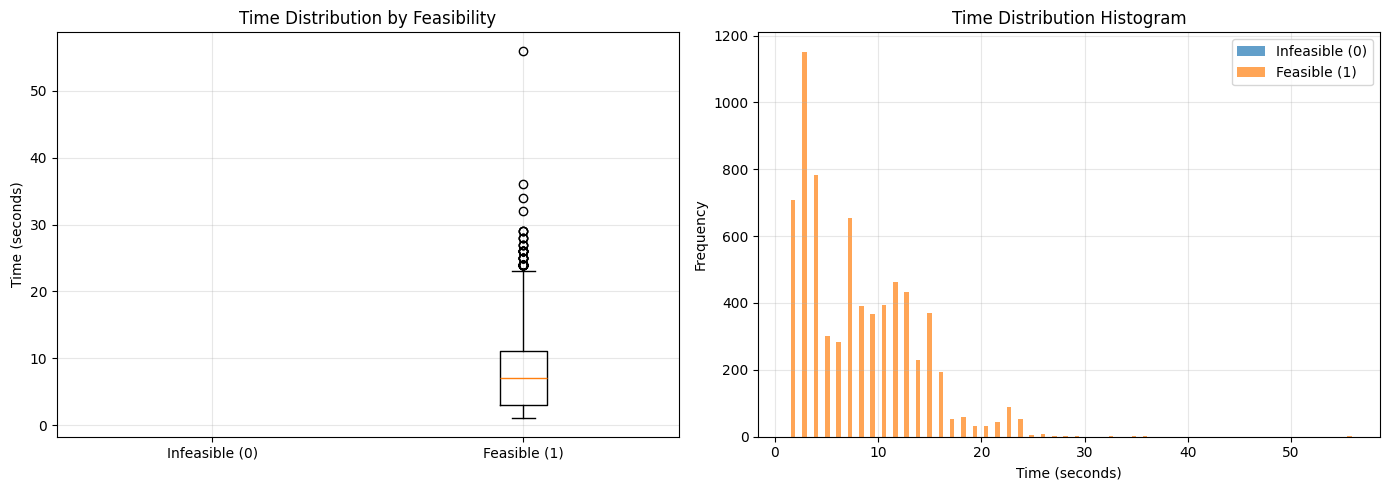

Time statistics by feasibility:
       count      mean       std  min  25%  50%   75%   max
feas                                                       
1     7110.0  7.936287  5.233043  1.0  3.0  7.0  11.0  56.0


In [74]:
# Time distribution by feasibility
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box plot: Time by feasibility
axes[0].boxplot([rrts[rrts['feas'] == 0]['time'], rrts[rrts['feas'] == 1]['time']], 
                    labels=['Infeasible (0)', 'Feasible (1)'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Time Distribution by Feasibility')
axes[0].grid(True, alpha=0.3)

# 2. Histogram: Time distribution for each feasibility
axes[1].hist([rrts[rrts['feas'] == 0]['time'], rrts[rrts['feas'] == 1]['time']], 
                bins=50, label=['Infeasible (0)', 'Feasible (1)'], alpha=0.7)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Time Distribution Histogram')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Time statistics by feasibility:")
print(rrts.groupby('feas')['time'].describe())

In [75]:
# what is the number of samples for every combination of planID and action_number
sample_counts = rrts.groupby(['planID', 'actionNum', 'plan']).size().reset_index(name='counts')
print("Sample counts for each combination of planID and action_number:")
print(sample_counts)

Sample counts for each combination of planID and action_number:
     planID  actionNum                                               plan  \
0         0          0  [[pick_touch, objectA, floor, ego], [place_str...   
1         0          1  [[pick_touch, objectA, floor, ego], [place_str...   
2         0          2  [[pick_touch, objectA, floor, ego], [place_str...   
3         0          3  [[pick_touch, objectA, floor, ego], [place_str...   
4         0          4  [[pick_touch, objectA, floor, ego], [place_str...   
..      ...        ...                                                ...   
323      49          3  [[pick_touch, objectA, floor, ego], [place_str...   
324      49          4  [[pick_touch, objectA, floor, ego], [place_str...   
325      49          5  [[pick_touch, objectA, floor, ego], [place_str...   
326      49          6  [[pick_touch, objectA, floor, ego], [place_str...   
327      49          7  [[pick_touch, objectA, floor, ego], [place_str...   

     counts

In [76]:
# for every combination of planID and action_number and plan, create the list of times and feasibilities
grouped_data_rrt = rrts.groupby(['planID', 'actionNum', 'plan']).agg({
    'time': lambda x: x.tolist(),
    'feas': lambda x: x.tolist()
}).reset_index()
grouped_data_rrt

,planID,actionNum,plan,time,feas
0,0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 7, 8, 7, 7, 22, 9, 7, 7, 21, 22, 10, 8, 11...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,0,1,"[[pick_touch, objectA, floor, ego], [place_str...","[16, 11, 11, 15, 11, 14, 10, 11, 10, 15, 15, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,0,2,"[[pick_touch, objectA, floor, ego], [place_str...","[18, 15, 15, 11, 15, 18, 17, 18, 20, 18, 9, 17...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,0,3,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 5, 10, 5, 10, 5, 10, 5, 6, 5, 12, 5, 8, 5,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,0,4,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 5, 8, 7, 8, 6, 8, 6, 11, 6, 9, 6, 8, 5, 8,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
...,...,...,...,...,...
323,49,3,"[[pick_touch, objectA, floor, ego], [place_str...","[2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1]"
324,49,4,"[[pick_touch, objectA, floor, ego], [place_str...","[5, 9, 1, 16, 9, 5]","[1, 1, 1, 1, 1, 1]"
325,49,5,"[[pick_touch, objectA, floor, ego], [place_str...","[4, 5, 3, 8, 6, 2]","[1, 1, 1, 1, 1, 1]"
326,49,6,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 4, 3, 3, 4, 5]","[1, 1, 1, 1, 1, 1]"


In [77]:
# add column for plan length. The plan length is array of arrays. I want the size of the first array
import re
def parse_list_of_lists(text):
    """
    Converts a string like:
      [[pick_touch, objectA, floor, ego], [place_straightOn_goal, objectA, ego, goalA]]
    into a real Python list of lists of strings.
    """
    # Add quotes around unquoted tokens (words, underscores, numbers)
    quoted = re.sub(r'([A-Za-z0-9_]+)', r'"\1"', text)

    # Now safely evaluate it as a Python literal
    return ast.literal_eval(quoted)
grouped_data_rrt['plan'] = grouped_data_rrt['plan'].apply(parse_list_of_lists)
grouped_data_rrt['plan_length'] = grouped_data_rrt['plan'].apply(lambda x: len(x))
grouped_data_rrt

,planID,actionNum,plan,time,feas,plan_length
0,0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 7, 8, 7, 7, 22, 9, 7, 7, 21, 22, 10, 8, 11...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6
1,0,1,"[[pick_touch, objectA, floor, ego], [place_str...","[16, 11, 11, 15, 11, 14, 10, 11, 10, 15, 15, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6
2,0,2,"[[pick_touch, objectA, floor, ego], [place_str...","[18, 15, 15, 11, 15, 18, 17, 18, 20, 18, 9, 17...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6
3,0,3,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 5, 10, 5, 10, 5, 10, 5, 6, 5, 12, 5, 8, 5,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6
4,0,4,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 5, 8, 7, 8, 6, 8, 6, 11, 6, 9, 6, 8, 5, 8,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6
...,...,...,...,...,...,...
323,49,3,"[[pick_touch, objectA, floor, ego], [place_str...","[2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1]",8
324,49,4,"[[pick_touch, objectA, floor, ego], [place_str...","[5, 9, 1, 16, 9, 5]","[1, 1, 1, 1, 1, 1]",8
325,49,5,"[[pick_touch, objectA, floor, ego], [place_str...","[4, 5, 3, 8, 6, 2]","[1, 1, 1, 1, 1, 1]",8
326,49,6,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 4, 3, 3, 4, 5]","[1, 1, 1, 1, 1, 1]",8


In [78]:
# create a json file like the waypoints one with get chain probs
rrt_data = {}
for i, row in grouped_data_rrt.iterrows():
    plan_id = row['planID']
    action_num = row['actionNum']
    plan = row['plan']
    times = row['time']
    feasibilities = row['feas']
    done_transitions, done_times, fail_transitions, fail_times = get_chain_probs(feasibilities, times)
    
    key = f"{plan_id}_action_{action_num}"
    rrt_data[key] = {
        'done_transitions': done_transitions.tolist(),
        'done_times': done_times.tolist(),
        'fail_transitions': fail_transitions.tolist(),
        'fail_times': fail_times.tolist(),
        'plan': plan,
        'planLength':row['plan_length']
    }

with open('rrt_chains.json', 'w') as f:
    json.dump(rrt_data, f, indent=4)


In [79]:
# calculate gittins index for each row in grouped_data_rrt
def compute_gi_rrt(row):
    times_array = row['time']
    feas_array = row['feas']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, times_array)
    mc = MarkovChain(np.array(done_values), np.array(done_times), np.array(fail_values), np.array(fail_times), BanditType.LINE)
    bp = BanditProcess([mc], [BanditType.LINE])
    return bp.get_gittins_index()[0]

def compute_stopping_time_rrt(row):
    times_array = row['time']
    feas_array = row['feas']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, times_array)
    mc = MarkovChain(np.array(done_values), np.array(done_times), np.array(fail_values), np.array(fail_times), BanditType.LINE)
    bp = BanditProcess([mc], [BanditType.LINE])
    return bp.get_gittins_index()[1]

grouped_data_rrt['gittins_index'] = grouped_data_rrt.apply(compute_gi_rrt, axis=1)
grouped_data_rrt['stopping_time'] = grouped_data_rrt.apply(compute_stopping_time_rrt, axis=1)

In [80]:
grouped_data_rrt

,planID,actionNum,plan,time,feas,plan_length,gittins_index,stopping_time
0,0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 7, 8, 7, 7, 22, 9, 7, 7, 21, 22, 10, 8, 11...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999009,21
1,0,1,"[[pick_touch, objectA, floor, ego], [place_str...","[16, 11, 11, 15, 11, 14, 10, 11, 10, 15, 15, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998734,15
2,0,2,"[[pick_touch, objectA, floor, ego], [place_str...","[18, 15, 15, 11, 15, 18, 17, 18, 20, 18, 9, 17...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998489,19
3,0,3,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 5, 10, 5, 10, 5, 10, 5, 6, 5, 12, 5, 8, 5,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999329,11
4,0,4,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 5, 8, 7, 8, 6, 8, 6, 11, 6, 9, 6, 8, 5, 8,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999292,10
...,...,...,...,...,...,...,...,...
323,49,3,"[[pick_touch, objectA, floor, ego], [place_str...","[2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1]",8,0.999800,1
324,49,4,"[[pick_touch, objectA, floor, ego], [place_str...","[5, 9, 1, 16, 9, 5]","[1, 1, 1, 1, 1, 1]",8,0.999400,0
325,49,5,"[[pick_touch, objectA, floor, ego], [place_str...","[4, 5, 3, 8, 6, 2]","[1, 1, 1, 1, 1, 1]",8,0.999533,7
326,49,6,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 4, 3, 3, 4, 5]","[1, 1, 1, 1, 1, 1]",8,0.999633,4


In [81]:
# add the average feasible time
def average_feasible_time(row):
    feas_array = row['feas']
    time_array = row['time']
    feas_times = [time_array[i] for i in range(len(feas_array)) if feas_array[i] == 1]
    if len(feas_times) == 0:
        return np.nan
    return np.mean(feas_times)

grouped_data_rrt['average_feasible_time'] = grouped_data_rrt.apply(average_feasible_time, axis=1)

In [82]:
grouped_data_rrt

,planID,actionNum,plan,time,feas,plan_length,gittins_index,stopping_time,average_feasible_time
0,0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 7, 8, 7, 7, 22, 9, 7, 7, 21, 22, 10, 8, 11...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999009,21,9.916667
1,0,1,"[[pick_touch, objectA, floor, ego], [place_str...","[16, 11, 11, 15, 11, 14, 10, 11, 10, 15, 15, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998734,15,12.666667
2,0,2,"[[pick_touch, objectA, floor, ego], [place_str...","[18, 15, 15, 11, 15, 18, 17, 18, 20, 18, 9, 17...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998489,19,15.125000
3,0,3,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 5, 10, 5, 10, 5, 10, 5, 6, 5, 12, 5, 8, 5,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999329,11,6.708333
4,0,4,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 5, 8, 7, 8, 6, 8, 6, 11, 6, 9, 6, 8, 5, 8,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999292,10,7.083333
...,...,...,...,...,...,...,...,...,...
323,49,3,"[[pick_touch, objectA, floor, ego], [place_str...","[2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1]",8,0.999800,1,2.000000
324,49,4,"[[pick_touch, objectA, floor, ego], [place_str...","[5, 9, 1, 16, 9, 5]","[1, 1, 1, 1, 1, 1]",8,0.999400,0,7.500000
325,49,5,"[[pick_touch, objectA, floor, ego], [place_str...","[4, 5, 3, 8, 6, 2]","[1, 1, 1, 1, 1, 1]",8,0.999533,7,4.666667
326,49,6,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 4, 3, 3, 4, 5]","[1, 1, 1, 1, 1, 1]",8,0.999633,4,3.666667


In [83]:
planid5 = grouped_data_rrt.iloc[30]
planid5

planID                                                                   5
actionNum                                                                0
plan                     [[pick_touch, objectA, floor, ego], [place_str...
time                     [9, 7, 20, 7, 12, 11, 12, 22, 22, 7, 7, 13, 22...
feas                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
plan_length                                                              6
gittins_index                                                     0.998723
stopping_time                                                           21
average_feasible_time                                             12.77551
Name: 30, dtype: object

In [84]:
# calculate the gittins index for this planid5
times_array = planid5['time']
feas_array = planid5['feas']
done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, times_array)
mc = MarkovChain(np.array(done_values), np.array(done_times), np.array(fail_values), np.array(fail_times), BanditType.LINE)
bp = BanditProcess([mc], [BanditType.LINE])
bp.state = 22
bp.get_gittins_index()

(np.float64(0.0), np.int64(0))

In [85]:
print(len(times_array))
print(max(times_array))

49
22


# LGP

In [86]:
lgp = pd.read_csv('aggregated_lgp.csv')
lgp = lgp[lgp['agent_number'] == 0]
print(f"After filtering for agent_number 0: {lgp.shape}")

After filtering for agent_number 0: (1130, 9)


In [87]:
lgp['time'] = np.ceil(lgp['time'] / 0.01).astype(int)
lgp

,file_id,agent_number,file_number,feas,time,evals,plan,planID,RRTPath
0,0,0,0,1,212,11,"[[pick_touch, objectA, floor, ego], [place_str...",0,"[0, 0,\n0.446808, -0.340971,\n0.957655, -0.540..."
1,0,0,0,1,183,11,"[[pick_touch, objectA, floor, ego], [place_str...",0,"[0, 0,\n0.425996, -0.332675,\n0.920241, -0.516..."
2,0,0,0,1,180,9,"[[pick_touch, objectA, floor, ego], [place_str...",0,"[0, 0,\n0.45953, -0.340689,\n0.976078, -0.5519..."
3,0,0,0,1,221,11,"[[pick_touch, objectA, floor, ego], [place_str...",0,"[0, 0,\n0.446638, -0.341277,\n0.957374, -0.540..."
4,0,0,0,1,200,10,"[[pick_touch, objectA, floor, ego], [place_str...",0,"[0, 0,\n0.425949, -0.332758,\n0.920187, -0.516..."
...,...,...,...,...,...,...,...,...,...
1125,0,0,0,1,265,11,"[[pick_touch, objectA, floor, ego], [place_str...",49,"[0, 0,\n0.592217, -0.299221,\n1.20071, -0.3640..."
1126,0,0,0,1,434,20,"[[pick_touch, objectA, floor, ego], [place_str...",49,"[0, 0,\n0.569912, -0.300964,\n1.16122, -0.3677..."
1127,0,0,0,0,194,5,"[[pick_touch, objectA, floor, ego], [place_str...",49,"[0, 0,\n0.425944, -0.332767,\n0.920181, -0.516..."
1128,0,0,0,1,176,7,"[[pick_touch, objectA, floor, ego], [place_str...",49,"[0, 0,\n0.592216, -0.299221,\n1.20071, -0.3640..."


In [88]:
# percentage of feasible runs
feas_percentage = lgp['feas'].mean() * 100
print(f"Percentage of feasible runs: {feas_percentage:.2f}%")

Percentage of feasible runs: 93.89%


/tmp/ipykernel_4711/2509244635.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([lgp[lgp['feas'] == 0]['time'], lgp[lgp['feas'] == 1]['time']],


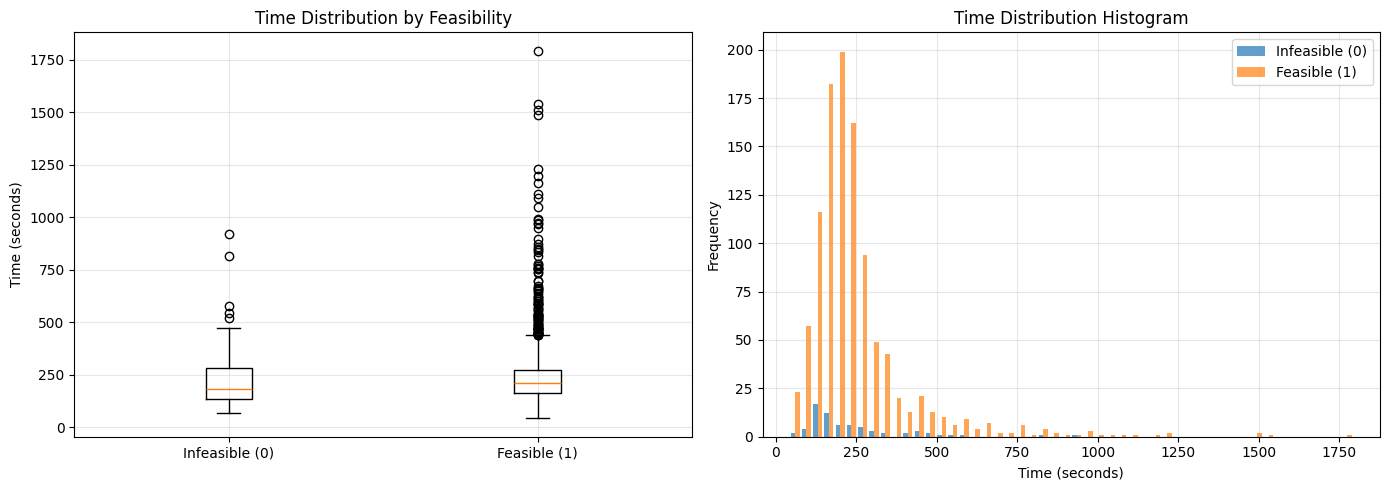

Time statistics by feasibility:
       count        mean         std   min    25%    50%    75%     max
feas                                                                   
0       69.0  242.695652  163.671506  69.0  134.0  182.0  284.0   920.0
1     1061.0  251.116871  173.760591  43.0  162.0  209.0  273.0  1793.0


In [89]:
# Time distribution by feasibility
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box plot: Time by feasibility
axes[0].boxplot([lgp[lgp['feas'] == 0]['time'], lgp[lgp['feas'] == 1]['time']], 
                    labels=['Infeasible (0)', 'Feasible (1)'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Time Distribution by Feasibility')
axes[0].grid(True, alpha=0.3)

# 2. Histogram: Time distribution for each feasibility
axes[1].hist([lgp[lgp['feas'] == 0]['time'], lgp[lgp['feas'] == 1]['time']], 
                bins=50, label=['Infeasible (0)', 'Feasible (1)'], alpha=0.7)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Time Distribution Histogram')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Time statistics by feasibility:")
print(lgp.groupby('feas')['time'].describe())

In [90]:
# what is the number of samples for every combination of planID and plan
sample_counts = lgp.groupby(['planID', 'plan']).size().reset_index(name='counts')
print("Sample counts for each combination of planID and plan:")
print(sample_counts)

Sample counts for each combination of planID and plan:
    planID                                               plan  counts
0        0  [[pick_touch, objectA, floor, ego], [place_str...      24
1        1  [[pick_touch, objectA, floor, ego], [place_str...      55
2        2  [[pick_touch, objectA, floor, ego], [place_str...      64
3        3  [[pick_touch, objectA, floor, ego], [place_str...      22
4        4  [[pick_touch, objectA, floor, ego], [place_str...      23
5        5  [[pick_touch, objectA, floor, ego], [place_str...      49
6        6  [[pick_touch, objectA, floor, ego], [place_str...      50
7        7  [[pick_touch, objectA, floor, ego], [place_str...      24
8        8  [[pick_touch, objectA, floor, ego], [place_str...      15
9        9  [[pick_touch, objectA, floor, ego], [place_str...      15
10      10  [[pick_touch, objectA, floor, ego], [place_str...       8
11      11  [[pick_touch, objectA, floor, ego], [place_str...      11
12      12  [[pick_touch, objectB, 

In [91]:
# what is the average time for feasible and infeasible runs and what is the average feasibility for each planID
avg_stats = lgp.groupby('planID').apply(lambda g: pd.Series({
    'feas_mean': g['feas'].mean(),
    'time_feas': g[g['feas'] == 1]['time'].mean(),
    'time_infeas': g[g['feas'] == 0]['time'].mean()
})).reset_index()
avg_stats

/tmp/ipykernel_4711/937798603.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_stats = lgp.groupby('planID').apply(lambda g: pd.Series({


,planID,feas_mean,time_feas,time_infeas
0,0,0.916667,249.681818,290.000000
1,1,0.890909,201.897959,167.833333
2,2,0.937500,222.483333,120.750000
3,3,1.000000,184.363636,NaN
4,4,1.000000,158.304348,NaN
5,5,0.918367,171.400000,235.250000
6,6,0.940000,196.127660,172.666667
7,7,0.916667,136.772727,124.500000
8,8,0.933333,185.357143,130.000000
9,9,0.933333,268.857143,122.000000


In [92]:
# for every combination of planID and plan, create the list of times and feasibilities
grouped_data = lgp.groupby(['planID', 'plan']).agg({
    'time': lambda x: x.tolist(),
    'feas': lambda x: x.tolist()
}).reset_index()
grouped_data

,planID,plan,time,feas
0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[212, 183, 180, 221, 200, 428, 532, 446, 308, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ..."
1,1,"[[pick_touch, objectA, floor, ego], [place_str...","[127, 199, 245, 262, 323, 161, 121, 109, 140, ...","[1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, ..."
2,2,"[[pick_touch, objectA, floor, ego], [place_str...","[248, 238, 222, 214, 264, 116, 439, 150, 138, ...","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, ..."
3,3,"[[pick_touch, objectA, floor, ego], [place_str...","[145, 237, 316, 162, 214, 206, 153, 196, 168, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,4,"[[pick_touch, objectA, floor, ego], [place_str...","[280, 140, 146, 124, 200, 65, 184, 153, 200, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
5,5,"[[pick_touch, objectA, floor, ego], [place_str...","[204, 243, 143, 167, 155, 165, 117, 163, 109, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
6,6,"[[pick_touch, objectA, floor, ego], [place_str...","[156, 155, 155, 181, 211, 203, 202, 201, 260, ...","[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7,7,"[[pick_touch, objectA, floor, ego], [place_str...","[115, 63, 127, 74, 65, 103, 168, 53, 70, 155, ...","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
8,8,"[[pick_touch, objectA, floor, ego], [place_str...","[209, 231, 181, 174, 175, 147, 278, 204, 135, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1]"
9,9,"[[pick_touch, objectA, floor, ego], [place_str...","[158, 346, 196, 253, 122, 179, 181, 474, 375, ...","[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"


In [93]:
# create a json file like the waypoints one with get chain probs
lgp_data = {}
for i, row in grouped_data.iterrows():
    plan_id = row['planID']
    plan = row['plan']
    times = row['time']
    feasibilities = row['feas']
    done_transitions, done_times, fail_transitions, fail_times = get_chain_probs(feasibilities, times)
    
    lgp_data[plan_id] = {
        'done_transitions': done_transitions.tolist(),
        'done_times': done_times.tolist(),
        'fail_transitions': fail_transitions.tolist(),
        'fail_times': fail_times.tolist(),
        'plan': plan
    }

with open('lgp_chains.json', 'w') as f:
    json.dump(lgp_data, f, indent=4)

In [94]:
grouped_data['stopping_time'] = grouped_data.apply(compute_stopping_time, axis=1)
grouped_data['gittins_index'] = grouped_data.apply(compute_gi, axis=1)

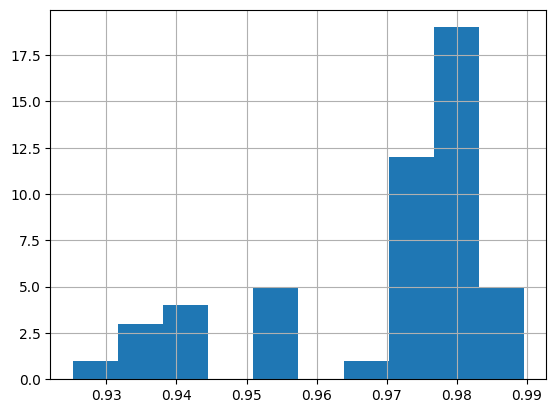

In [95]:
grouped_data['gittins_index'].hist()
plt.show()

In [96]:
grouped_data.sort_values('gittins_index', ascending=False).head(10)

,planID,plan,time,feas,stopping_time,gittins_index
17,17,"[[pick_touch, objectB, floor, ego], [place_str...","[151, 146, 125, 85, 95, 56, 88, 147, 48]","[1, 1, 1, 1, 1, 1, 1, 1, 1]",150,0.989605
35,35,"[[pick_touch, objectC, floor, ego], [place_str...","[165, 147, 112, 102, 185, 153, 163, 102, 100, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",184,0.986440
7,7,"[[pick_touch, objectA, floor, ego], [place_str...","[115, 63, 127, 74, 65, 103, 168, 53, 70, 155, ...","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",201,0.985571
21,21,"[[pick_touch, objectB, floor, ego], [place_str...","[188, 221, 182, 153, 815, 216, 155, 97, 236, 1...","[1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",282,0.984434
4,4,"[[pick_touch, objectA, floor, ego], [place_str...","[280, 140, 146, 124, 200, 65, 184, 153, 200, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",331,0.984313
13,13,"[[pick_touch, objectB, floor, ego], [place_str...","[111, 124, 217, 246, 136, 194, 184]","[1, 1, 1, 1, 1, 1, 1]",245,0.982845
11,11,"[[pick_touch, objectA, floor, ego], [place_str...","[232, 138, 192, 89, 140, 672, 142, 154, 191, 1...","[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",191,0.982084
3,3,"[[pick_touch, objectA, floor, ego], [place_str...","[145, 237, 316, 162, 214, 206, 153, 196, 168, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",318,0.981747
5,5,"[[pick_touch, objectA, floor, ego], [place_str...","[204, 243, 143, 167, 155, 165, 117, 163, 109, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",242,0.981550
10,10,"[[pick_touch, objectA, floor, ego], [place_str...","[197, 238, 164, 87, 228, 101, 182, 128]","[1, 1, 1, 1, 1, 1, 1, 0]",237,0.981276


In [97]:
grouped_data['feas_avg'] = grouped_data['feas'].apply(lambda x: np.mean(x))
grouped_data.sort_values('feas_avg', ascending=False).head(10)

,planID,plan,time,feas,stopping_time,gittins_index,feas_avg
4,4,"[[pick_touch, objectA, floor, ego], [place_str...","[280, 140, 146, 124, 200, 65, 184, 153, 200, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",331,0.984313,1.0
3,3,"[[pick_touch, objectA, floor, ego], [place_str...","[145, 237, 316, 162, 214, 206, 153, 196, 168, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",318,0.981747,1.0
17,17,"[[pick_touch, objectB, floor, ego], [place_str...","[151, 146, 125, 85, 95, 56, 88, 147, 48]","[1, 1, 1, 1, 1, 1, 1, 1, 1]",150,0.989605,1.0
13,13,"[[pick_touch, objectB, floor, ego], [place_str...","[111, 124, 217, 246, 136, 194, 184]","[1, 1, 1, 1, 1, 1, 1]",245,0.982845,1.0
15,15,"[[pick_touch, objectB, floor, ego], [place_str...","[147, 270, 208, 220, 261, 188, 169, 162, 212, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",342,0.977997,1.0
35,35,"[[pick_touch, objectC, floor, ego], [place_str...","[165, 147, 112, 102, 185, 153, 163, 102, 100, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",184,0.986440,1.0
44,44,"[[pick_touch, objectA, floor, ego], [place_str...","[699, 778, 1232, 834, 161, 363, 475, 234, 588]","[1, 1, 1, 1, 1, 1, 1, 1, 1]",1231,0.942604,1.0
43,43,"[[pick_touch, objectA, floor, ego], [place_str...","[699, 333, 443, 447, 292, 535]","[1, 1, 1, 1, 1, 1]",698,0.955300,1.0
36,36,"[[pick_touch, objectA, floor, ego], [place_str...","[343, 525, 651, 544, 741, 196, 235]","[1, 1, 1, 1, 1, 1, 1]",740,0.955013,1.0
39,39,"[[pick_touch, objectA, floor, ego], [place_str...","[126, 110, 436, 325, 394, 348, 242, 433]","[1, 1, 1, 1, 1, 1, 1, 1]",435,0.970346,1.0


# Which plan is the Best?

In [98]:
grouped_data_rrt

,planID,actionNum,plan,time,feas,plan_length,gittins_index,stopping_time,average_feasible_time
0,0,0,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 7, 8, 7, 7, 22, 9, 7, 7, 21, 22, 10, 8, 11...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999009,21,9.916667
1,0,1,"[[pick_touch, objectA, floor, ego], [place_str...","[16, 11, 11, 15, 11, 14, 10, 11, 10, 15, 15, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998734,15,12.666667
2,0,2,"[[pick_touch, objectA, floor, ego], [place_str...","[18, 15, 15, 11, 15, 18, 17, 18, 20, 18, 9, 17...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.998489,19,15.125000
3,0,3,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 5, 10, 5, 10, 5, 10, 5, 6, 5, 12, 5, 8, 5,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999329,11,6.708333
4,0,4,"[[pick_touch, objectA, floor, ego], [place_str...","[7, 5, 8, 7, 8, 6, 8, 6, 11, 6, 9, 6, 8, 5, 8,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",6,0.999292,10,7.083333
...,...,...,...,...,...,...,...,...,...
323,49,3,"[[pick_touch, objectA, floor, ego], [place_str...","[2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1]",8,0.999800,1,2.000000
324,49,4,"[[pick_touch, objectA, floor, ego], [place_str...","[5, 9, 1, 16, 9, 5]","[1, 1, 1, 1, 1, 1]",8,0.999400,0,7.500000
325,49,5,"[[pick_touch, objectA, floor, ego], [place_str...","[4, 5, 3, 8, 6, 2]","[1, 1, 1, 1, 1, 1]",8,0.999533,7,4.666667
326,49,6,"[[pick_touch, objectA, floor, ego], [place_str...","[3, 4, 3, 3, 4, 5]","[1, 1, 1, 1, 1, 1]",8,0.999633,4,3.666667


In [99]:
results_df = pd.DataFrame(columns=['planID', 'gittins_index', 'stopping_time'])

for i, row in df.iterrows():
    feas_array = row['feas']
    time_array = row['time']
    done_values, done_times, fail_values, fail_times = get_chain_probs(feas_array, time_array)
    mc = MarkovChain(done_values, done_times, fail_values, fail_times, BanditType.LINE)
    markov_chains = [mc]
    bandit_types = [BanditType.LINE]
    # collect rrts relevant to that planID
    plan_id = row['planID']
    rrts_plan = grouped_data_rrt[grouped_data_rrt['planID'] == plan_id]
    plan_length = rrts_plan['plan_length'].values[0]
    for j in range(plan_length):
        rrt_row = rrts_plan[rrts_plan['actionNum'] == j].iloc[0]
        if rrt_row.empty:
            raise ValueError(f"No RRT data for PlanID {plan_id} and ActionNum {j}")
        rrt_done_values, rrt_done_times, rrt_fail_values, rrt_fail_times = get_chain_probs(rrt_row['feas'], rrt_row['time'])
        rrt_mc = MarkovChain(rrt_done_values, rrt_done_times, rrt_fail_values, rrt_fail_times, BanditType.LINE)
        markov_chains.append(rrt_mc)
        bandit_types.append(BanditType.LINE)
    # collect lgp relevant to that planID
    lgp_plan = grouped_data[grouped_data['planID'] == plan_id].iloc[0]
    if lgp_plan.empty:
        raise ValueError(f"No LGP data for PlanID {plan_id}")
    lgp_done_values, lgp_done_times, lgp_fail_values, lgp_fail_times = get_chain_probs(lgp_plan['feas'], lgp_plan['time'])
    lgp_mc = MarkovChain(lgp_done_values, lgp_done_times, lgp_fail_values, lgp_fail_times, BanditType.LINE)
    markov_chains.append(lgp_mc)
    bandit_types.append(BanditType.LINE)
    bp = BanditProcess(markov_chains, bandit_types)
    gi, stopping_time = bp.get_gittins_index()    
    results_df = pd.concat([results_df, pd.DataFrame([{
    'planID': plan_id,
    'gittins_index': gi,
    'stopping_time': stopping_time
}])], ignore_index=True)

/tmp/ipykernel_4711/4114824896.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([{


In [100]:
results_df.sort_values('gittins_index', ascending=False).head(50) # beta is 0.999

,planID,gittins_index,stopping_time
55,5,0.969080,5
5,5,0.968903,5
81,31,0.967689,5
31,31,0.967576,6
52,2,0.966135,6
2,2,0.965948,6
71,21,0.965409,6
21,21,0.965077,6
57,7,0.964451,5
7,7,0.964446,5


In [101]:
results_df.sort_values('gittins_index', ascending=False).head(50) # beta is 0.99

,planID,gittins_index,stopping_time
55,5,0.969080,5
5,5,0.968903,5
81,31,0.967689,5
31,31,0.967576,6
52,2,0.966135,6
2,2,0.965948,6
71,21,0.965409,6
21,21,0.965077,6
57,7,0.964451,5
7,7,0.964446,5
